### Here we'll be downloading and looking at visualizing scRNA-seq data.

First, we'll import the relevant packages; scanpy, and anndata.

In [43]:
import scanpy as sc
import anndata as an
import pandas as pd



Now we'll import some data to get an understanding of how scRNA-seq data is stored, and how to visualize it.

In [44]:
X = an.read_h5ad("/opt/andrew/lupus/lupus.h5ad")
X = an.AnnData(X.raw.X, X.obs, X.raw.var)

X.obs = X.obs.rename(
        {
            "batch_cov": "pool",
            "ind_cov": "patient",
            "cg_cov": "Cell Type",
            "ct_cov": "cell_type_lympho",
            "ind_cov_batch_cov": "Condition",
            "Age": "age",
            "Sex": "sex",
            "pop_cov": "ancestry",
        },
        axis=1,
    )

Let's look at what is contained in an AnnData object, which contains the scRNA-seq data.

In [45]:
print(X)


AnnData object with n_obs × n_vars = 1263676 × 32738
    obs: 'pool', 'patient', 'Processing_Cohort', 'louvain', 'Cell Type', 'cell_type_lympho', 'L3', 'Condition', 'age', 'sex', 'ancestry', 'Status', 'SLE_status'
    var: 'gene_ids', 'feature_types-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0'


So we have identifying labels for each rows (X.obs), and genes themselves (X.var). Let's look at obs first. This is a pandas datafame containing individual cell's information, like which drug it was treated with.

In [46]:
print(type(X.obs))
print(X.obs.reset_index())

<class 'pandas.core.frame.DataFrame'>
                                                     index  \
0        CAAGGCCAGTATCGAA-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0...   
1        CTAACTTCAATGAATG-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0...   
2        AAGTCTGGTCTACCTC-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0...   
3        GGCTCGATCGTTGACA-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0...   
4        ACACCGGCACACAGAG-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0...   
...                                                    ...   
1263671  GAATGAACACCGGAAA-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0...   
1263672  TAGCCGGGTACCGAGA-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0...   
1263673  AACTCTTTCCGTAGGC-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0...   
1263674  AGCTCCTGTAACGTTC-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0...   
1263675  CTGCGGAGTGATAAGT-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0...   

                                 pool            patient Processing_Cohort  \
0                  dmx_YS-JY-22_pool6             HC-546               4.0   
1                  dmx_YS-JY-22_pool6          1132_1132     

Now let's look at vars - this contains the name of each gene.

In [47]:
print(type(X.var))
print(X.var.index)

<class 'pandas.core.frame.DataFrame'>
Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10',
       ...
       'KIR3DL2-1', 'AL590523.1', 'CT476828.1', 'PNRC2-1', 'SRSF10-1',
       'AC145205.1', 'BAGE5', 'CU459201.1', 'AC002321.2', 'AC002321.1'],
      dtype='object', length=32738)


Finally let's look at some the raw data. This is contained in the .X portion of the anndata object. This is a sparse matrix to save space for now - this will be converted to a dense matrix for you as you process the data.

In [48]:
print(type(X.X))
print(X.X[0:50, 0:50])

<class 'scipy.sparse._csr.csr_matrix'>
  (2, 42)	1.0
  (4, 27)	1.0
  (4, 42)	1.0
  (5, 42)	1.0
  (12, 35)	1.0
  (12, 42)	1.0
  (13, 42)	3.0
  (15, 35)	1.0
  (17, 42)	1.0
  (19, 42)	1.0
  (26, 42)	2.0
  (27, 27)	1.0
  (27, 42)	6.0
  (28, 35)	1.0
  (28, 42)	5.0
  (30, 42)	3.0
  (32, 42)	1.0
  (37, 42)	1.0
  (39, 42)	1.0
  (42, 42)	1.0
  (43, 27)	1.0
  (44, 42)	1.0
  (45, 42)	2.0
  (46, 42)	2.0


Now we can proceed with data normalization and preprocessing. Let's only look at the first processing cohort condition, take a subset of those cells and then proceed.

In [49]:
X_ctrl = X[X.obs.Processing_Cohort == '1.0', :]
X_ctrl = X_ctrl[0: 10000, :]

In [50]:
print(X_ctrl)

View of AnnData object with n_obs × n_vars = 10000 × 32738
    obs: 'pool', 'patient', 'Processing_Cohort', 'louvain', 'Cell Type', 'cell_type_lympho', 'L3', 'Condition', 'age', 'sex', 'ancestry', 'Status', 'SLE_status'
    var: 'gene_ids', 'feature_types-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0'


Ok now we have about 180k cells. Go ahead and preprocess these, cluster them with leiden clustering, construct a umap, and label the cells. You should broadly see CD4 cells, CD8 cells, NK cells, and monocytes. Once you've labeled those make a umap of these cell labels, and then you're good to go! Base this on the PBMC 3k dataset labeling from scanpy online. Have fun :-)

In [51]:
# Work goes here.
#pre processing XD
sc.pp.filter_cells(X_ctrl, min_genes=200)
sc.pp.filter_genes(X_ctrl, min_cells=3)


X_ctrl.var['mt'] = X_ctrl.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(X_ctrl, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

X_ctrl = X_ctrl[X_ctrl.obs.n_genes_by_counts < 2500, :]
X_ctrl = X_ctrl[X_ctrl.obs.pct_counts_mt < 5, :].copy()

sc.pp.normalize_total(X_ctrl, target_sum=1e4)

sc.pp.log1p(X_ctrl)

sc.pp.highly_variable_genes(X_ctrl, min_mean=0.0125, max_mean=3, min_disp=0.5)

X_ctrl = X_ctrl[:, X_ctrl.var.highly_variable]

sc.pp.regress_out(X_ctrl, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(X_ctrl, max_value=10)


filtered out 14932 genes that are detected in less than 3 cells


/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:00:09)


computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:01)


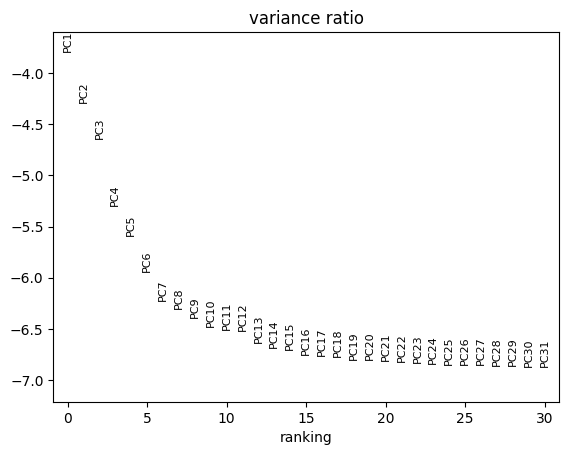

AnnData object with n_obs × n_vars = 7628 × 2296
    obs: 'pool', 'patient', 'Processing_Cohort', 'louvain', 'Cell Type', 'cell_type_lympho', 'L3', 'Condition', 'age', 'sex', 'ancestry', 'Status', 'SLE_status', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [52]:
sc.tl.pca(X_ctrl, svd_solver="arpack")
sc.pl.pca_variance_ratio(X_ctrl, log=True)
X_ctrl

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished (0:00:00)
computing UMAP
    finished (0:00:06)


/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


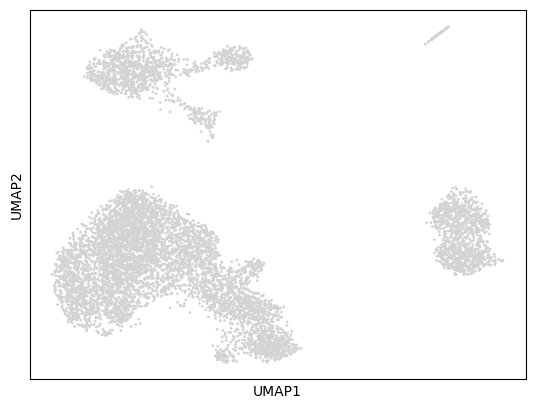

In [53]:
sc.pp.neighbors(X_ctrl, n_neighbors=10, n_pcs=40)
sc.tl.umap(X_ctrl)
sc.pl.umap(X_ctrl)



var names:  ['HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'PUSL1', 'ATAD3C', 'ATAD3A', 'MIB2', 'MMP23B', 'RP5-892K4.1', 'RP3-395M20.12', 'TPRG1L', 'WRAP73', 'SMIM1', 'C1orf174', 'PHF13', 'THAP3', 'UTS2', 'ENO1-AS1', 'CA6', 'GPR157', 'RBP7', 'CASZ1', 'FBXO2', 'TNFRSF8', 'EFHD2', 'FBXO42', 'RP4-798A10.7', 'CROCC', 'CAMK2N1', 'CDA', 'PINK1', 'EIF4G3', 'USP48', 'C1QA', 'C1QB', 'LUZP1', 'ID3', 'RUNX3', 'RP1-187B23.1', 'STMN1', 'ZNF593', 'ZNF683', 'FGR', 'IFI6', 'EYA3', 'RP5-1092A3.4', 'SNHG12', 'EPB41', 'MATN1-AS1', 'PUM1', 'ZCCHC17', 'CCDC28B', 'SYNC', 'RNF19B', 'RP4-728D4.2', 'CLSPN', 'AGO1', 'CSF3R', 'LINC01137', 'C1orf122', 'FHL3', 'RLF', 'HIVEP3', 'LEPRE1', 'SLC2A1', 'MED8', 'PTCH2', 'IPP', 'MOB3C', 'ATPAF1', 'CDKN2C', 'GPX7', 'SLC1A7', 'RP11-117D22.2', 'YIPF1', 'CYB5RL', 'SSBP3', 'TTC22', 'JUN', 'L1TD1', 'GADD45A', 'ACADM', 'RP11-386I14.4', 'IFI44L', 'RP5-887A10.1', 'RP11-486G15.2', 'RP4-612B15.3', 'LMO4', 'GTF2B', 'CCBL2', 'GBP1', 'GBP4', 'GBP5', 'TGFBR3', 'GFI1', 'FNBP1L', 'CNN3', 'SLC35

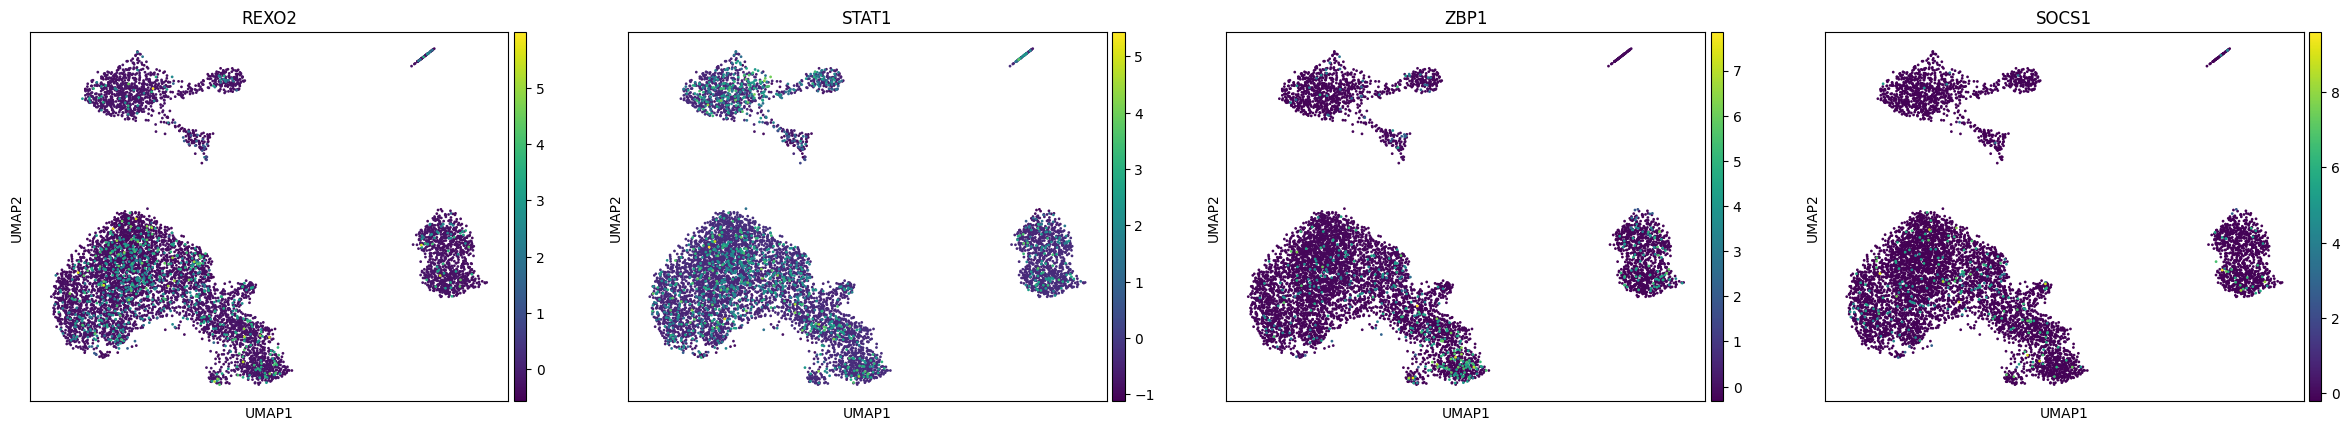

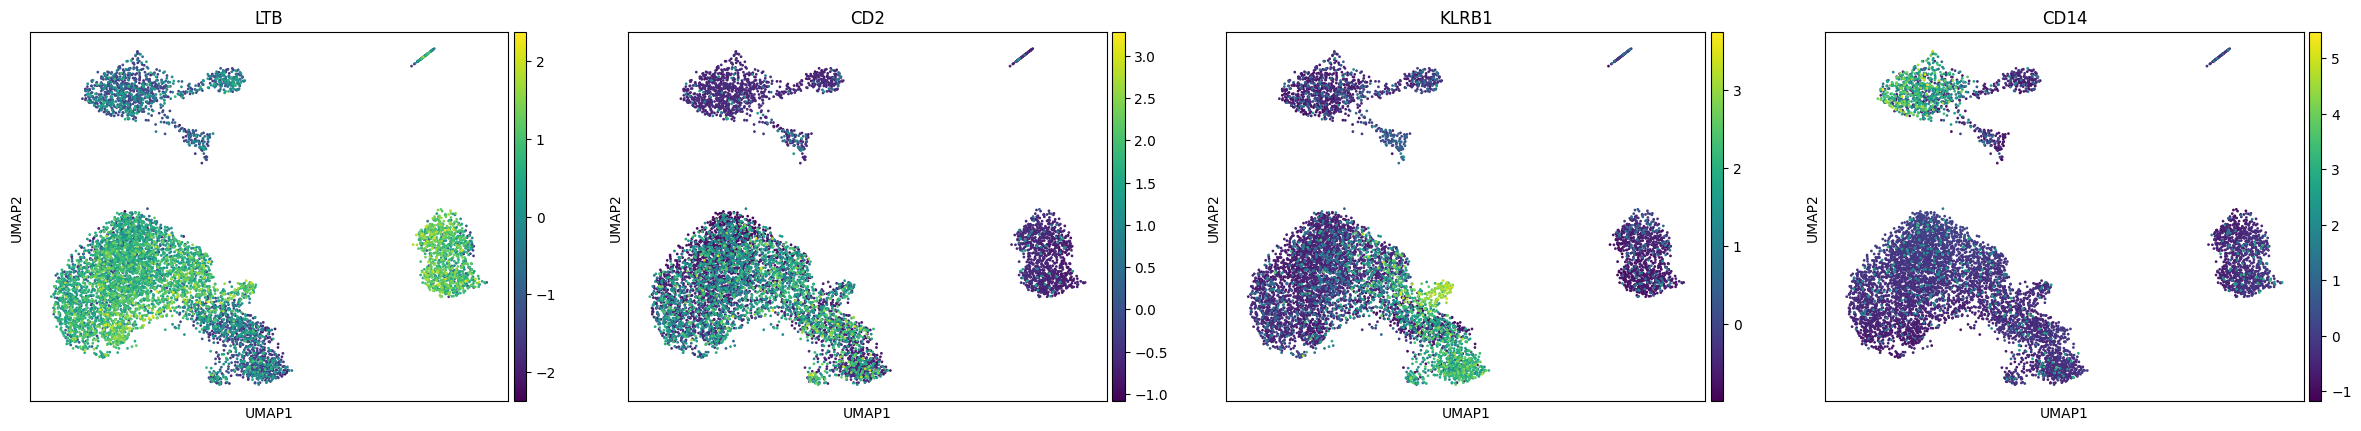

In [56]:
print("var names: ", list(X_ctrl.var_names))
sc.pl.umap(X_ctrl, color=["REXO2", "STAT1", "ZBP1", "SOCS1"])
sc.pl.umap(X_ctrl, color=["LTB", "CD2", "KLRB1", "CD14"])

running Leiden clustering
    finished (0:00:00)


/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


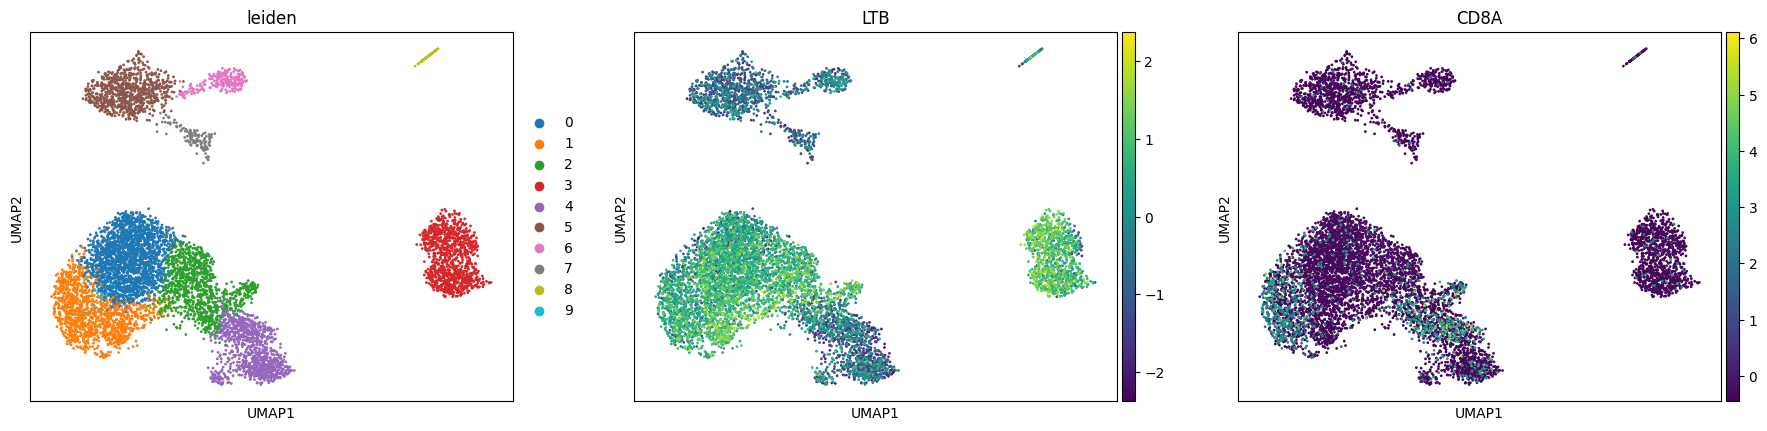

In [ ]:
sc.tl.leiden(
    X_ctrl,
    resolution=0.9,
    random_state=0,
    n_iterations=2,
    directed=False,
)
sc.pl.umap(X_ctrl, color=["leiden", "LTB", "CD8A"])

ranking genes
    finished (0:00:00)


/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/helenk/.cache/pypoetry/virtualenvs/bicytok

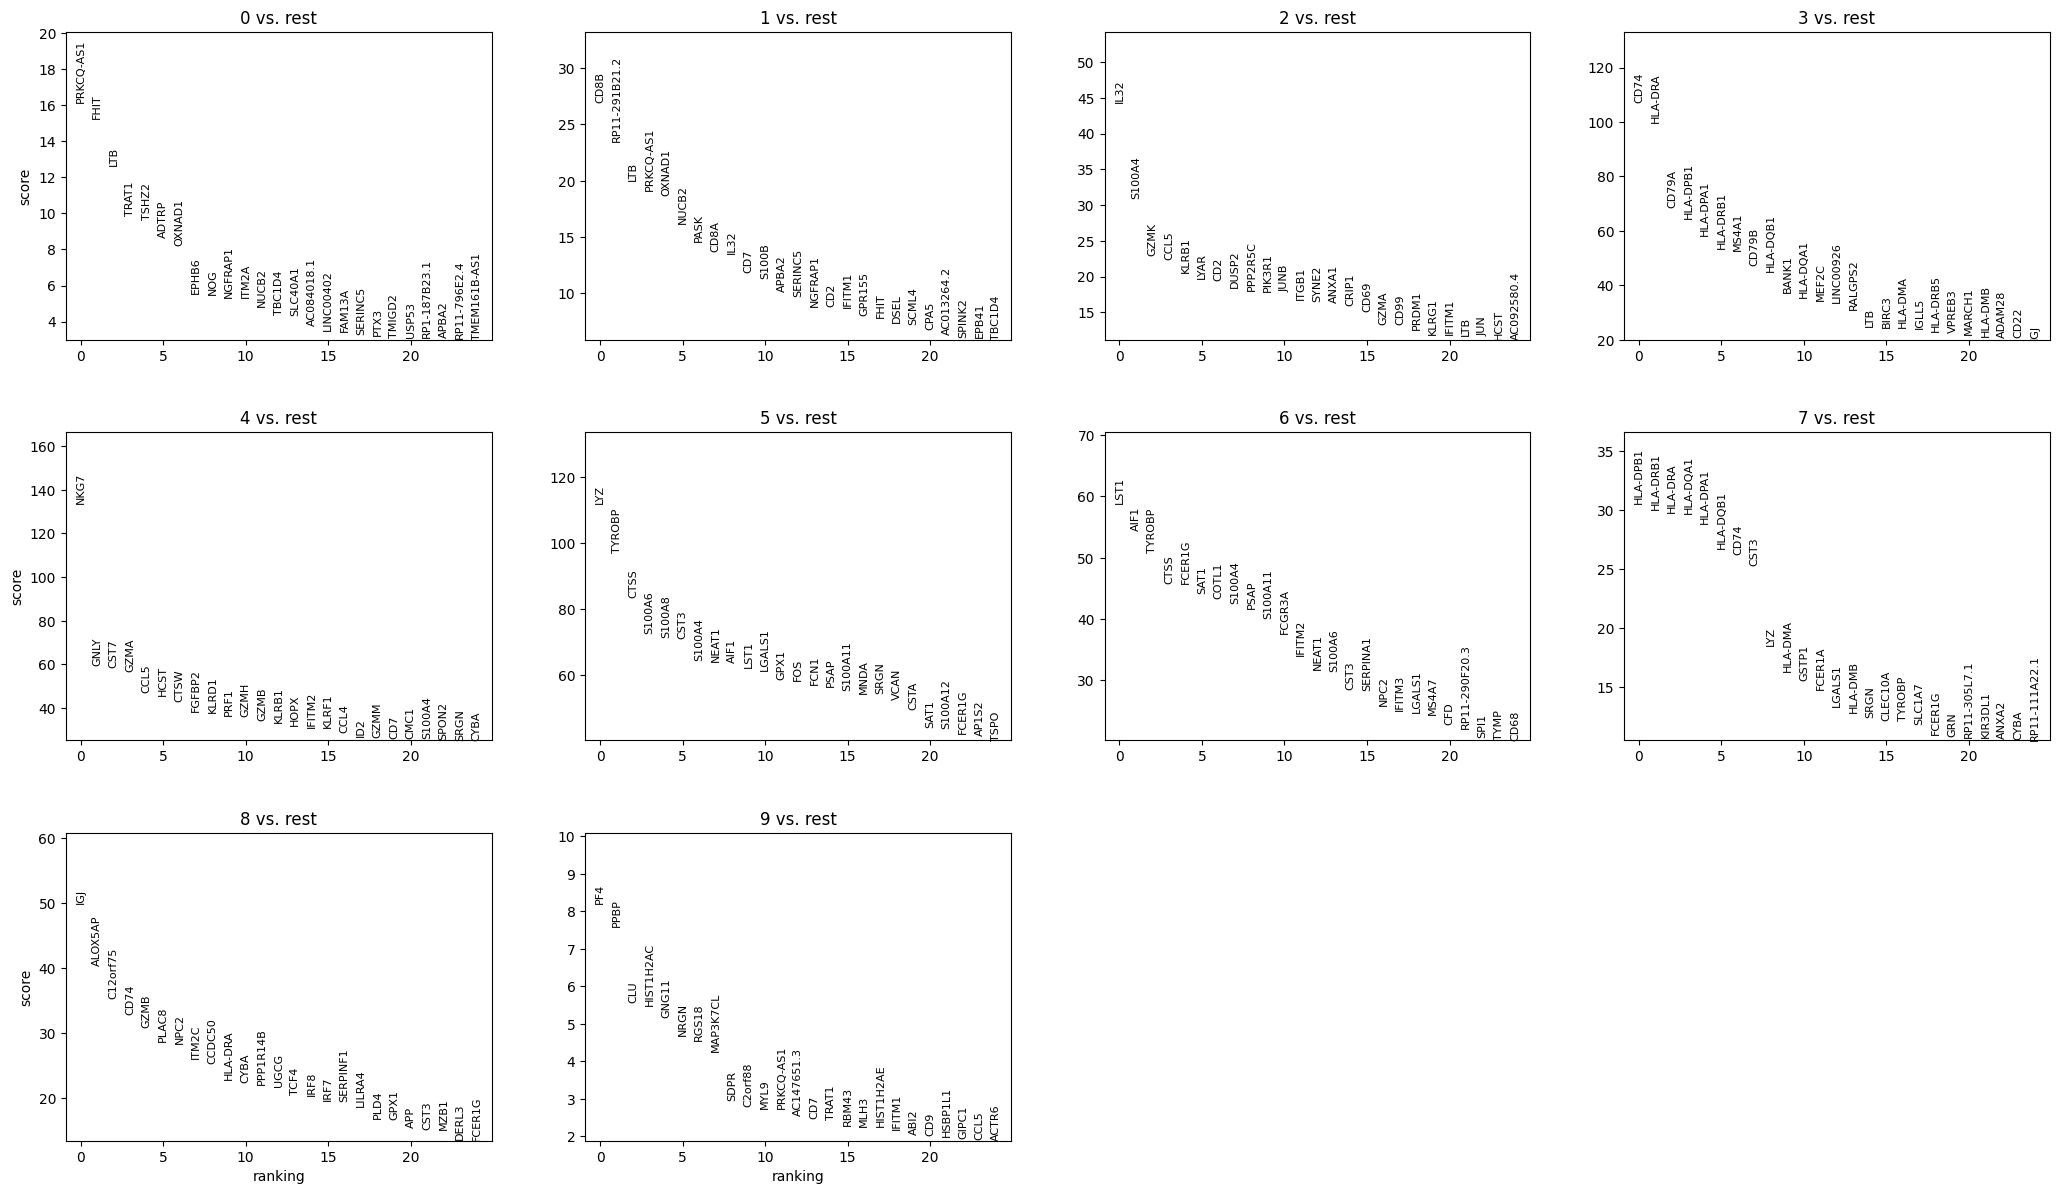

ranking genes
    finished (0:00:01)


/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/helenk/.cache/pypoetry/virtualenvs/bicytok

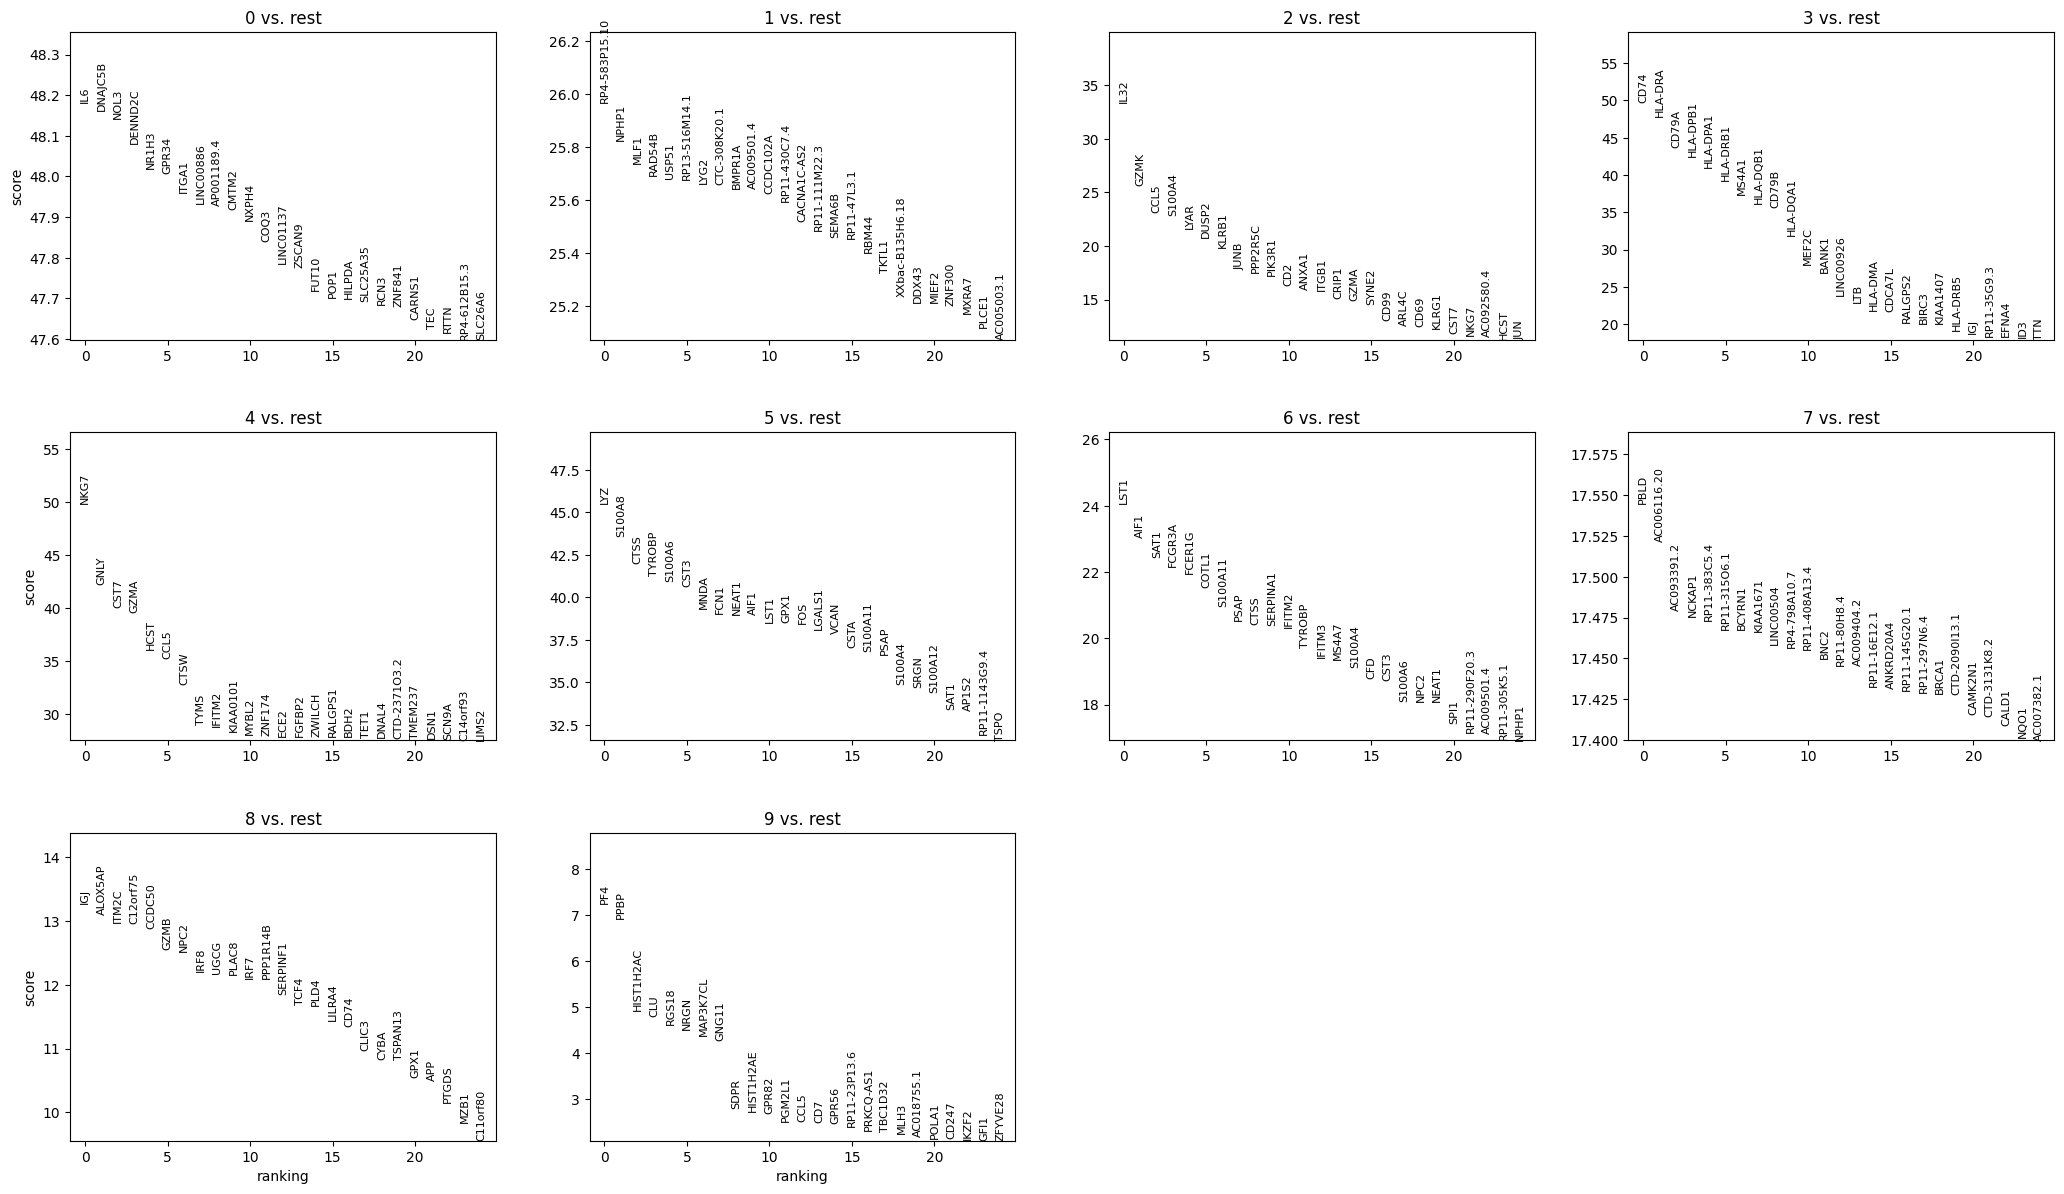

In [ ]:
sc.tl.rank_genes_groups(X_ctrl, "leiden", method="t-test")
sc.pl.rank_genes_groups(X_ctrl, n_genes=25, sharey=False)
sc.settings.verbosity = 2 
sc.tl.rank_genes_groups(X_ctrl, "leiden", method="wilcoxon")
sc.pl.rank_genes_groups(X_ctrl, n_genes=25, sharey=False)

ranking genes
    finished (0:00:00)


/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


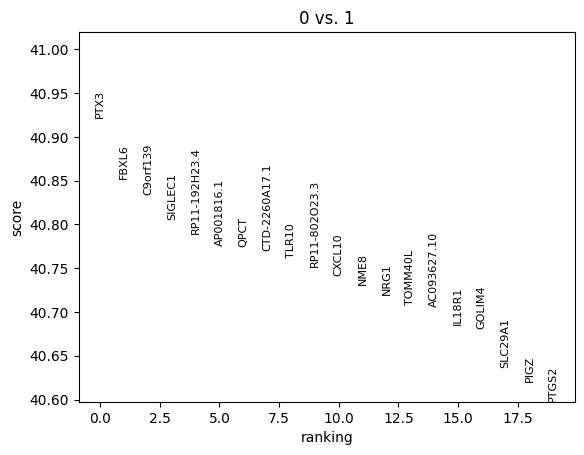

In [ ]:
pd.DataFrame(X_ctrl.uns["rank_genes_groups"]["names"]).head(5)
result = X_ctrl.uns["rank_genes_groups"]
groups = result["names"].dtype.names
pd.DataFrame(
    {
        group + "_" + key[:1]: result[key][group]
        for group in groups
        for key in ["names", "pvals"]
    }
).head(5)
sc.tl.rank_genes_groups(X_ctrl, "leiden", groups=["0"], reference="1", method="wilcoxon")
sc.pl.rank_genes_groups(X_ctrl, groups=["0"], n_genes=20)

In [ ]:
pd.DataFrame(X_ctrl.uns["rank_genes_groups"]["names"]).head(5)

,0
0,PTX3
1,FBXL6
2,C9orf139
3,SIGLEC1
4,RP11-192H23.4


/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/__init__.py:1170: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  _ax = sns.violinplot(
/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/__init__.py:1183: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  _ax = sns.stripplot(
/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/__init__.py:1199: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation='vertical')


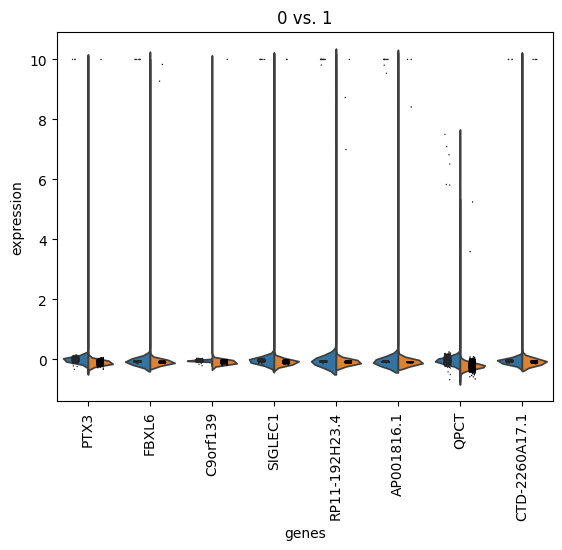

/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/helenk/.cache/pypoetry/virtualenvs/bicytok-o364XjTL-py3.11/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/home/helenk/.cache/pypoetry/virtualenvs/bicyto

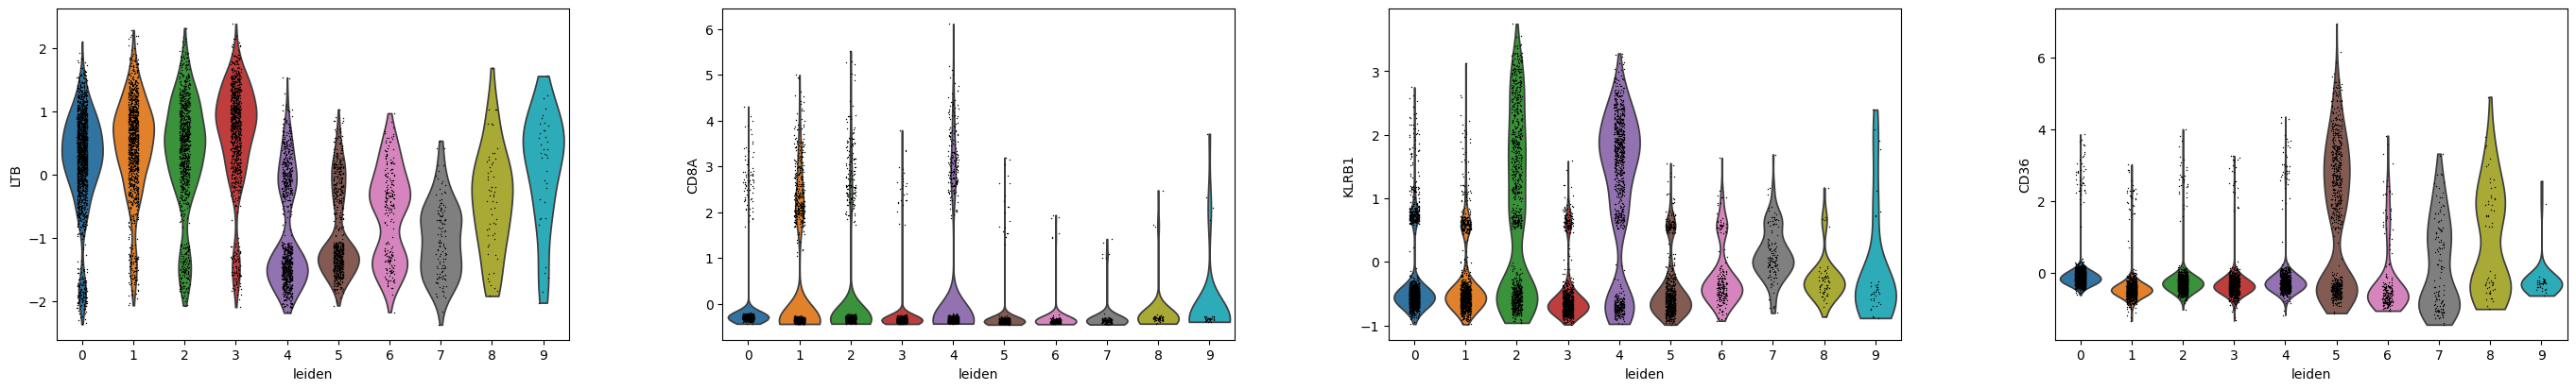

In [ ]:
marker_genes = [
    *["IL7R", "CD79A", "MS4A1", "CD8A", "CD8B", "LYZ", "CD14"],
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"],
]
sc.pl.rank_genes_groups_violin(X_ctrl, groups="0", n_genes=8)
sc.pl.violin(X_ctrl, ["LTB", "CD8A", "KLRB1", "CD36"], groupby="leiden")



In [ ]:
new_cluster_names = [
    "CD4 T",
    "B",
    "FCGR3A+ Monocytes",
    "NK",
    "CD8 T",
    "CD14+ Monocytes",
    "Dendritic",
    "Megakaryocytes",
]
X_ctrl.rename_categories("leiden", new_cluster_names)

sc.pl.umap(
    X_ctrl, color="leiden", legend_loc="on data", title="", frameon=False, save=".pdf"
)